In [42]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv('music_streams.csv')

In [3]:
df.head()

,track_id,title,artist,genre,year,duration,duration_sec,tempo_bpm,key,energy,...,valence,acousticness,speechiness,loudness_db,explicit,streams_millions,monthly_listeners,playlist_adds,chart_peak,label
0,TRK00001,Memories,Juno Calloway,R&B,2024,3:15,195,85,F Minor,0.502,...,0.872,0.694,0.148,-8.8,False,3.73,176,8336,NaN,AWAL
1,TRK00002,Tears,Cleo Nova,Indie,2020,2:40,160,68,F# Major,0.610,...,0.545,0.485,0.111,-3.9,False,3.10,170,1625,NaN,A24 Sounds
2,TRK00003,Soul,Cole Voss ft. Indigo Ashford,Rock,2017,3:55,235,140,D Major,0.742,...,0.483,0.281,0.050,-4.1,True,18.22,770,42971,NaN,Dead Oceans
3,TRK00004,Heart,Asha Ashford,Rock,2022,3:05,185,73,A Major,0.643,...,0.634,0.505,0.092,-8.6,False,0.23,1,484,NaN,Sony Music
4,TRK00005,Bones,Theo Blaine,Hip-Hop,2015,3:09,189,143,G# Major,0.770,...,0.223,0.394,0.105,-13.4,False,0.72,1,1101,NaN,A24 Sounds


In [11]:
df.describe()

,year,duration_sec,tempo_bpm,energy,danceability,valence,acousticness,speechiness,loudness_db,streams_millions,monthly_listeners,playlist_adds,chart_peak
count,1200.000000,1200.000000,1200.00000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,398.000000
mean,2020.416667,208.478333,111.85000,0.630888,0.420776,0.490212,0.492011,0.162236,-7.632583,10.171200,547.436667,18006.349167,35.271357
std,2.572983,38.430439,24.02079,0.197475,0.185624,0.190506,0.199972,0.175026,3.440571,23.480756,1167.522745,41026.124735,42.904225
min,2015.000000,90.000000,60.00000,0.062000,0.000000,0.023000,0.000000,0.006000,-20.000000,0.050000,1.000000,50.000000,1.000000
25%,2018.000000,183.000000,89.00000,0.487000,0.291000,0.352000,0.354750,0.057000,-9.900000,1.740000,95.750000,2483.750000,9.000000
50%,2021.000000,208.000000,117.00000,0.641500,0.426000,0.498500,0.486500,0.101000,-7.600000,4.060000,223.000000,6641.500000,19.000000
75%,2023.000000,234.000000,131.00000,0.773250,0.545000,0.623250,0.630000,0.190500,-5.300000,10.330000,555.250000,17412.750000,43.000000
max,2024.000000,325.000000,165.00000,1.000000,1.000000,0.969000,1.000000,1.000000,-1.000000,523.170000,16655.000000,646358.000000,200.000000


In [4]:
df.columns

Index(['track_id', 'title', 'artist', 'genre', 'year', 'duration',
       'duration_sec', 'tempo_bpm', 'key', 'energy', 'danceability', 'valence',
       'acousticness', 'speechiness', 'loudness_db', 'explicit',
       'streams_millions', 'monthly_listeners', 'playlist_adds', 'chart_peak',
       'label'],
      dtype='object')

# Histograms

### monthly streams histogram

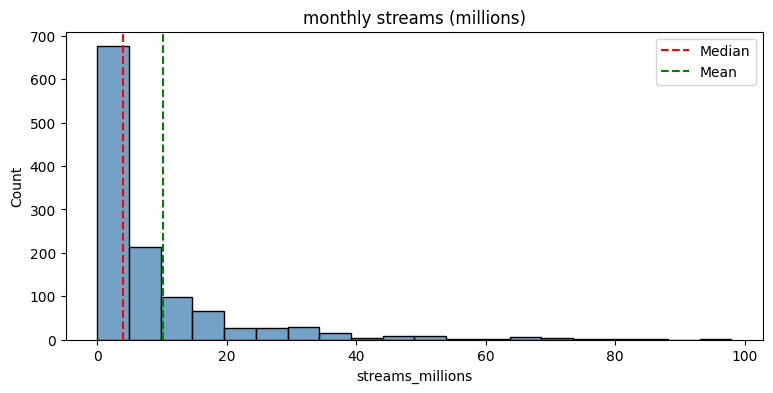

In [25]:
fig, ax = plt.subplots(figsize=(9,4))
median = df.streams_millions.median()
mean = df.streams_millions.mean()
sns.histplot(data=df[df.streams_millions < 100], x="streams_millions", bins = 20, ax=ax, color='steelblue')
ax.axvline(median, color='red', label='Median', linestyle='--')
ax.axvline(mean, color='green', label='Mean', linestyle='--')
ax.legend()
ax.set_title("monthly streams (millions)")
plt.show()

### Energy histogram

<Axes: xlabel='energy', ylabel='Count'>

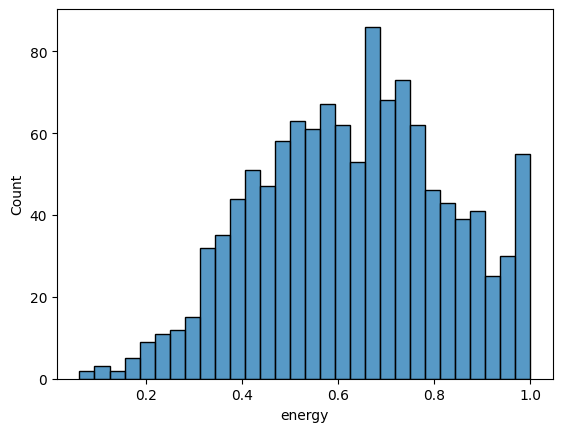

In [30]:
sns.histplot(data=df, x='energy', bins=30)

# Boxplots

### energy per genre

In [34]:
order = df.groupby('genre')['energy'].median().sort_values(ascending=False).index
order

Index(['Electronic', 'Rock', 'Latin', 'Hip-Hop', 'Pop', 'Country', 'Indie',
       'R&B'],
      dtype='object', name='genre')

<Axes: xlabel='genre', ylabel='energy'>

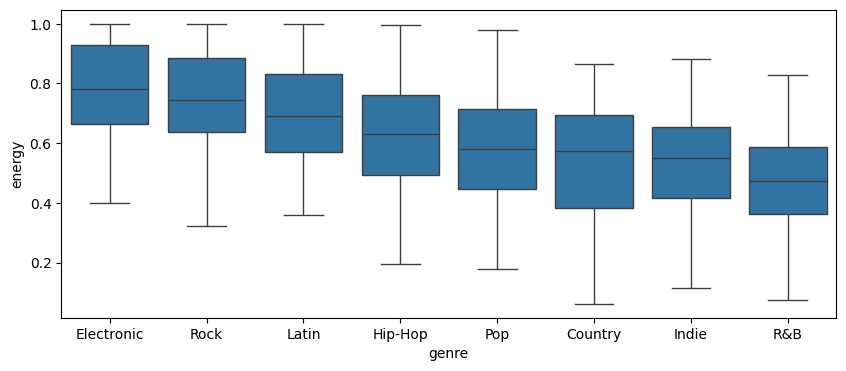

In [36]:
fig, ax= plt.subplots(figsize=(10,4))
sns.boxplot(data=df, y='energy', x='genre', order=order, ax=ax)

### acousticness per genre

<Axes: xlabel='genre', ylabel='acousticness'>

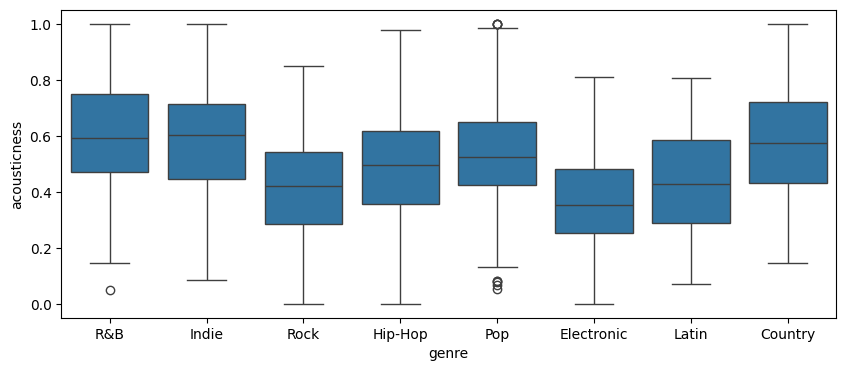

In [41]:
fig, ax = plt.subplots(figsize=(10,4))
sns.boxplot(data=df, y='acousticness', x='genre', ax=ax)

### monthly listeners per genre

In [45]:
df["monthly_listeners_millions"] = np.log(df["monthly_listeners"])
df["monthly_listeners"]

0        176
1        170
2        770
3          1
4          1
        ... 
1195     446
1196    1597
1197     180
1198     309
1199     431
Name: monthly_listeners, Length: 1200, dtype: int64

# Scatterplots

### energy by danceability

<Axes: xlabel='energy', ylabel='danceability'>

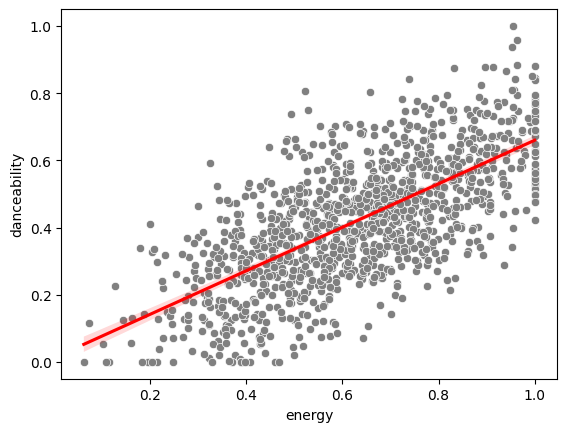

In [50]:
sns.scatterplot(data=df, x='energy', y='danceability', color='grey')
sns.regplot(data=df, x='energy', y='danceability', scatter=False, color='red')

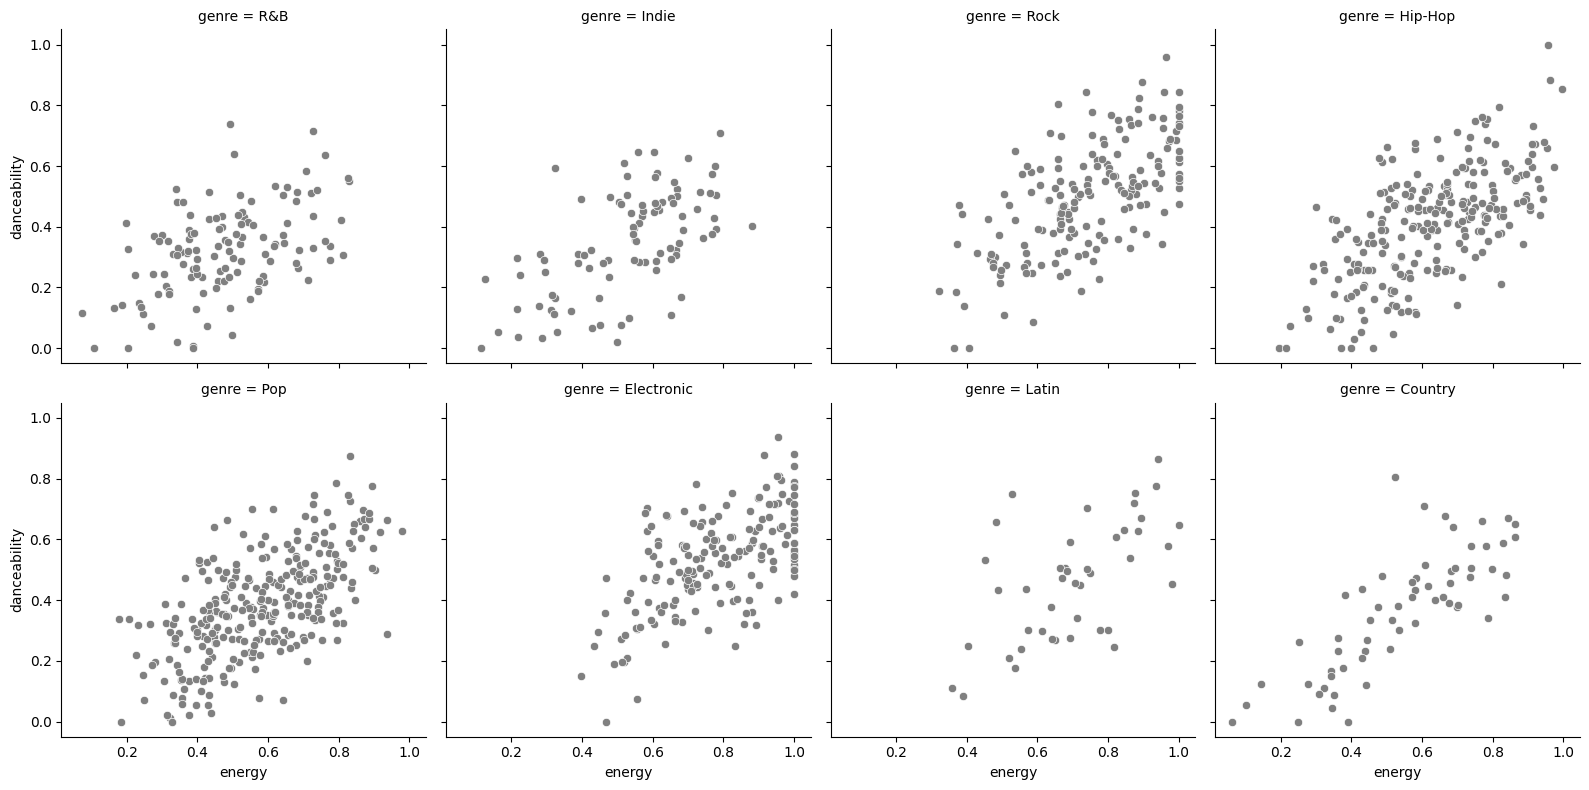

In [51]:
g=sns.FacetGrid(df, col='genre', col_wrap=4, height=4)
g.map(sns.scatterplot, 'energy', 'danceability', color='grey')

### energy by loudness

<Axes: xlabel='energy', ylabel='loudness_db'>

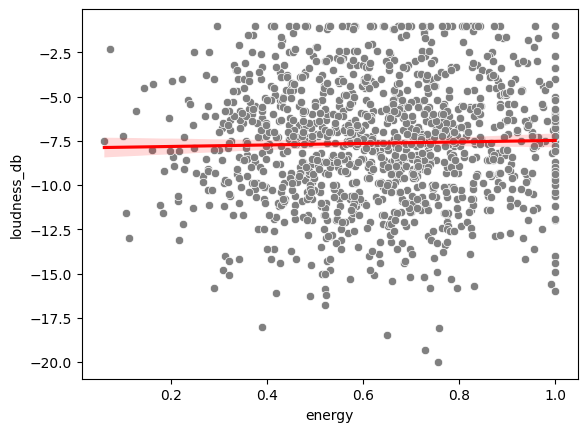

In [53]:
sns.scatterplot(data=df, x='energy', y='loudness_db', color='grey')
sns.regplot(data=df, x='energy', y='loudness_db', scatter=False, color='red')

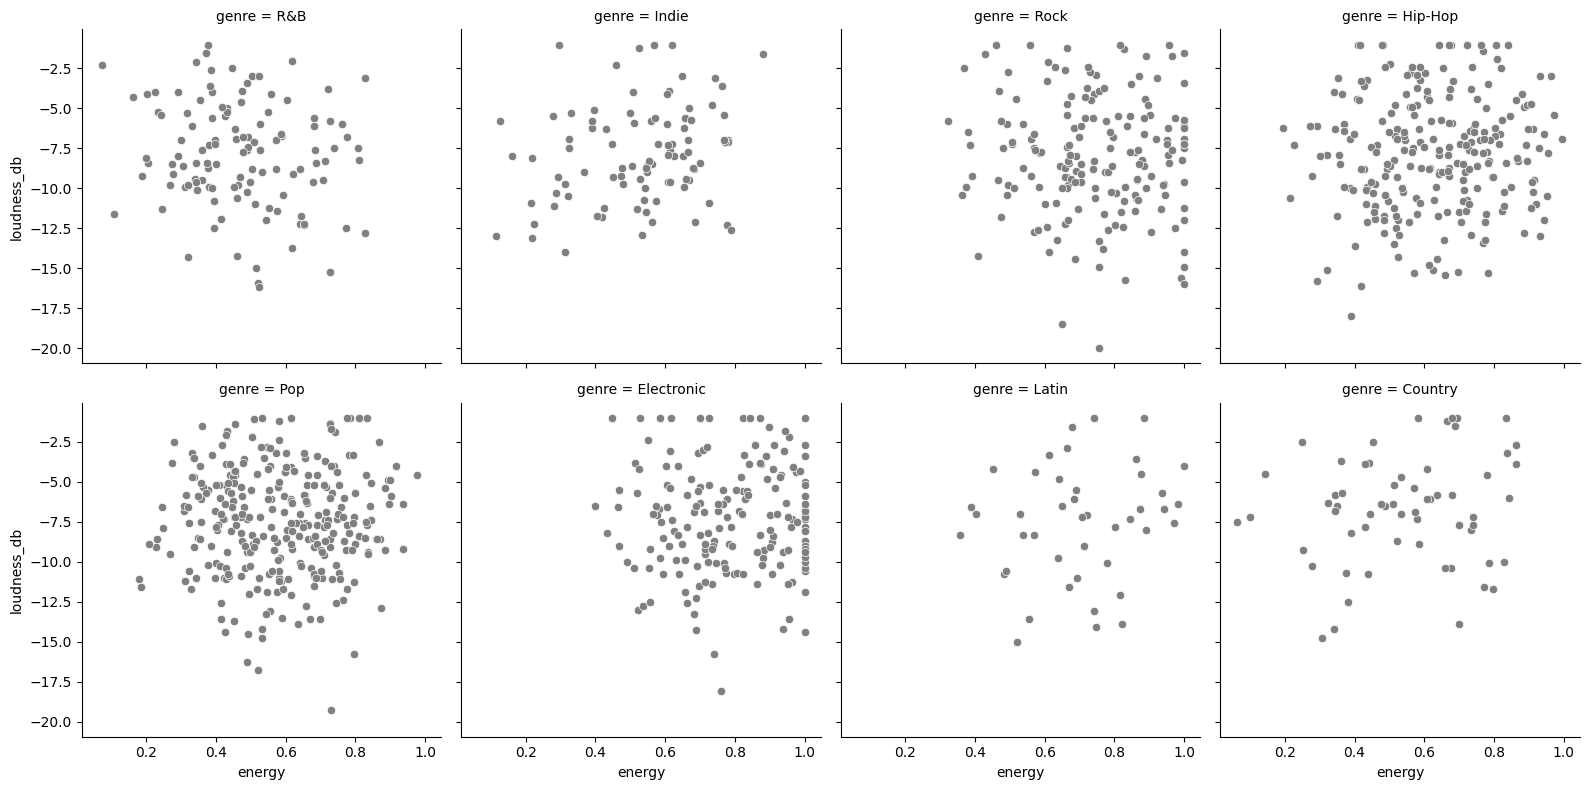

In [54]:
g = sns.FacetGrid(df, col='genre', col_wrap=4, height=4)
g.map(sns.scatterplot, 'energy', 'loudness_db', color='grey')

# Line Charts and Friends

### median streams (millions) over time by genre

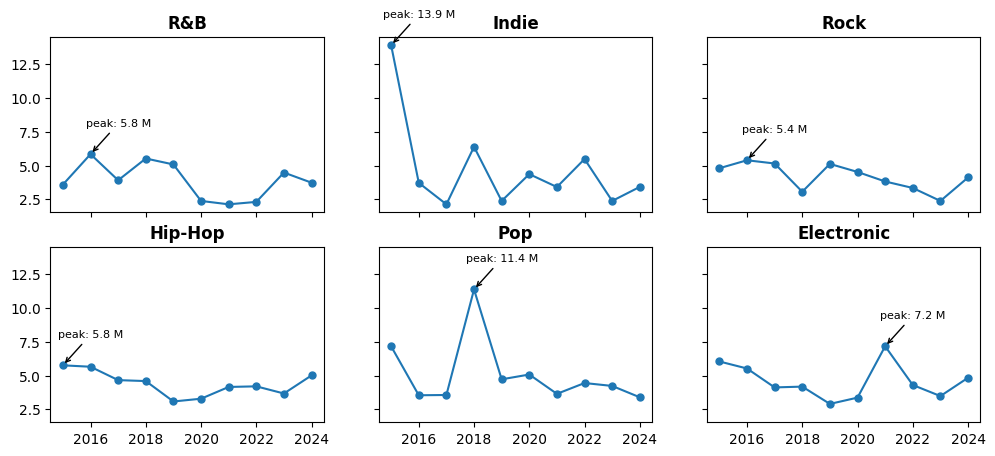

In [57]:
genres = df.genre.unique()

trend = df[df.genre.isin(genres)].groupby(["year", "genre"])["streams_millions"].median().reset_index()

fig, axes = plt.subplots(2,3, figsize=(12,5), sharex=True, sharey=True)
axes=axes.flatten()

for ax, genre in zip(axes, genres):
    subD=trend[trend.genre == genre]
    ax.plot(subD.year, subD.streams_millions, marker='o', ms=5)
    peak = subD.loc[subD.streams_millions.idxmax()]
    ax.annotate(f"peak: {peak.streams_millions:.1f} M", xy=(peak.year, peak.streams_millions), xytext=(20,20), textcoords="offset points", ha="center", fontsize=8, arrowprops=dict(arrowstyle="->", color='black', lw=1))
    ax.set_title(genre, fontweight='bold')

### median valence over time by genre

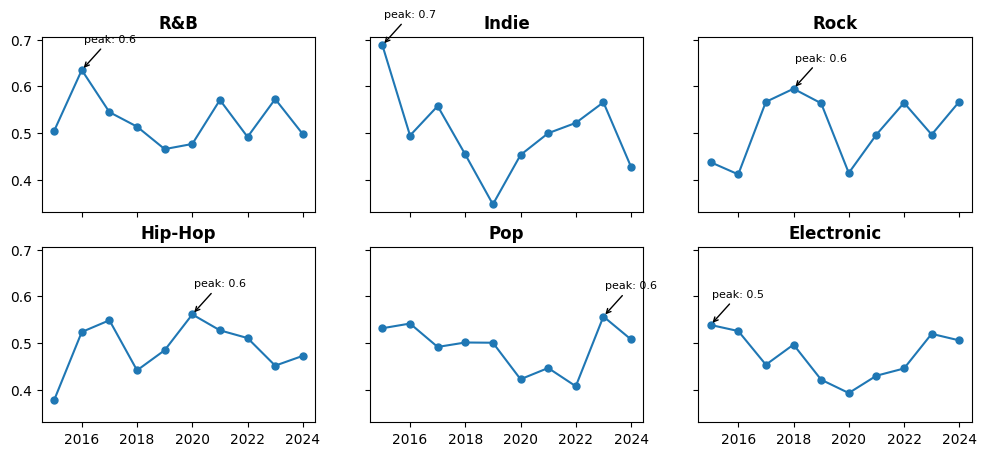

In [58]:
genres = df.genre.unique()

trend = df[df.genre.isin(genres)].groupby(["year", "genre"])["valence"].median().reset_index()

fig, axes = plt.subplots(2,3, figsize=(12,5), sharex=True, sharey=True)
axes=axes.flatten()

for ax, genre in zip(axes, genres):
    subD=trend[trend.genre == genre]
    ax.plot(subD.year, subD.valence, marker='o', ms=5)
    peak = subD.loc[subD.valence.idxmax()]
    ax.annotate(f"peak: {peak.valence:.1f}", xy=(peak.year, peak.valence), xytext=(20,20), textcoords="offset points", ha="center", fontsize=8, arrowprops=dict(arrowstyle="->", color='black', lw=1))
    ax.set_title(genre, fontweight='bold')

# Interactive Bar Chart using Altair 

### Median Monthly Streams per Genre bar chart. highlight on hover. select on click. 

In [62]:
import altair as alt

In [ ]:
## median monthly streams per genre bar chart using altair. highlight on hover. select on click. 

genre_streams = df.groupby("genre")["streams_millions"].median().reset_index()

hover = alt.selection_point(fields=["genre"], on="mouseover", empty=False)
click = alt.selection_point(fields=["genre"], empty=False)

bar = alt.Chart(genre_streams).mark_bar().encode(
    x=alt.X("genre:N", sort="-y", title="Genre"),
    y=alt.Y("streams_millions:Q", title="Median Streams (Millions)"),
    color=alt.condition(click, alt.Color("genre:N", legend=None), alt.value("lightgrey")),
    opacity=alt.condition(hover, alt.value(1), alt.value(0.7)),
    tooltip=["genre:N", alt.Tooltip("streams_millions:Q", format=".2f", title="Median Streams (M)")]
).add_params(
    hover,
    click
).properties(
    title="Median Monthly Streams by Genre",
    width=500,
    height=350
)

bar


alt.Chart(...)